In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')

deliveries_df['extra_runs'] = deliveries_df['extra_runs'].fillna(0)
deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('none')

deliveries_df_filtered = deliveries_df[deliveries_df['inning'].isin([1, 2])].copy()

extras_per_match = deliveries_df_filtered.groupby(
    ['match_id', 'bowling_team', 'inning']
)['extra_runs'].sum().reset_index()

avg_extras = extras_per_match.groupby(
    ['bowling_team', 'inning']
)['extra_runs'].mean().reset_index(name='avg_extras_per_match')

display(avg_extras)

,bowling_team,inning,avg_extras_per_match
0,Chennai Super Kings,1,7.722222
1,Chennai Super Kings,2,7.753846
2,Deccan Chargers,1,9.187500
3,Deccan Chargers,2,8.488372
4,Delhi Capitals,1,8.420000
5,Delhi Capitals,2,7.390244
6,Delhi Daredevils,1,8.067416
7,Delhi Daredevils,2,7.746479
8,Gujarat Lions,1,5.625000
9,Gujarat Lions,2,7.000000


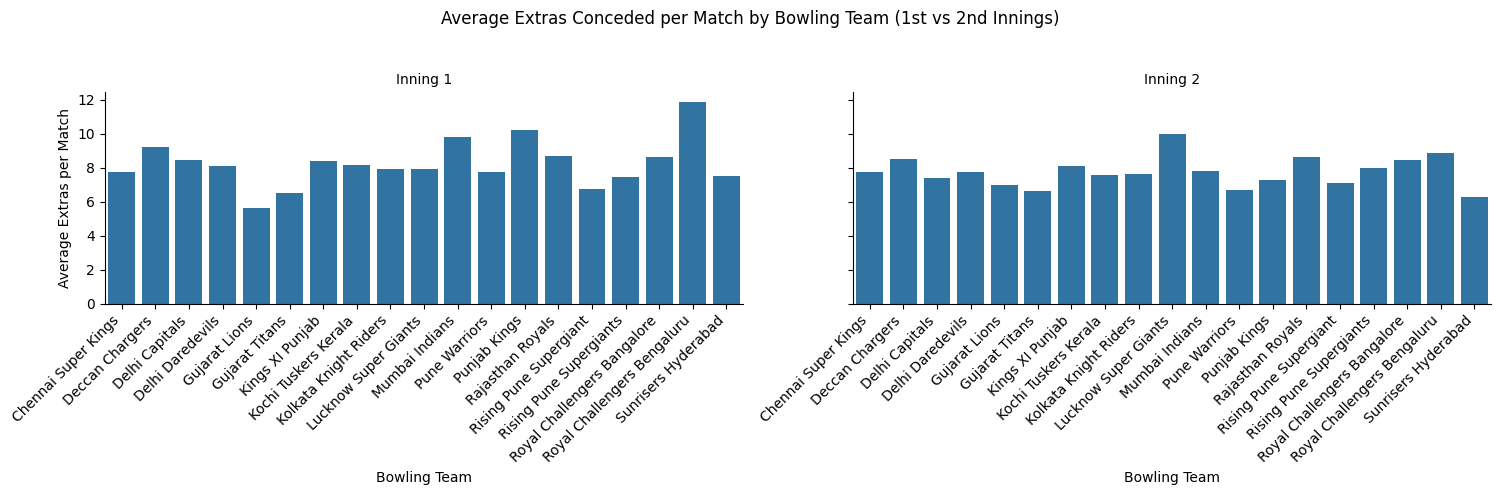

In [9]:
g = sns.catplot(
    data=avg_extras,
    x='bowling_team',
    y='avg_extras_per_match',
    col='inning',
    kind='bar',
    height=5,
    aspect=1.5
)

g.set_axis_labels('Bowling Team', 'Average Extras per Match')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')

plt.suptitle('Average Extras Conceded per Match by Bowling Team (1st vs 2nd Innings)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()